# A. IMPORT ĐỦ CÁC THƯ VIỆN

In [1]:
# Libraries
import numpy as np
import pandas as pd
from requests import head
from sklearn import *
# Preprocessing
from src.preprocessing import *
# Visualization
from src.visualization import *
path = "data\\jewelry.csv"

# B. ĐỔI TÊN CỘT VÀ ĐỌC FILE

In [2]:
column_names = [
    'event_time',    # Thời gian mua hàng
    'order_id',      # Mã đơn hàng
    'product_id',    # Mã sản phẩm
    'quantity',      # Số lượng
    'category_id',   # Mã danh mục
    'category_code', # Tên loại trang sức
    'brand_id',      # Mã thương hiệu
    'price',         # Giá tiền
    'user_id',       # Mã khách hàng
    'gender',        # Giới tính
    'color',         # Màu sắc (red, white, gold...)
    'metal',         # Chất liệu kim loại (gold, silver...)
    'gem'            # Loại đá quý (diamond, sapphire...)
]

# Ép về string
# tránh để string dài quá đọc csv sẽ tự chuyển sang int64
dtype_specs = {
    'order_id': str,
    'product_id': str,
    'category_id': str,
    'brand_id': str,
    'user_id': str,
    'category_code': str
}
dataset = pd.read_csv(path, header=None, names=column_names, dtype=dtype_specs)

*XEM THÔNG TIN KIỂU DỮ LIỆU CÁC CỘT SAU KHI ĐỌC

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 95911 entries, 0 to 95910
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     95911 non-null  str    
 1   order_id       95911 non-null  str    
 2   product_id     95911 non-null  str    
 3   quantity       95911 non-null  int64  
 4   category_id    90559 non-null  str    
 5   category_code  85978 non-null  str    
 6   brand_id       91126 non-null  str    
 7   price          90559 non-null  float64
 8   user_id        90559 non-null  str    
 9   gender         47743 non-null  str    
 10  color          88251 non-null  str    
 11  metal          90449 non-null  str    
 12  gem            61853 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 9.5 MB


# C. TIỀN XỬ LÝ DỮ LIỆU

In [4]:
data_outputs = master_preprocessing_pipeline(dataset)
df_main = data_outputs['main_clean']
df_rules = data_outputs['rules_data']
df_users = data_outputs['user_profile']

display(df_users.head())
display(df_rules.head(15))

,user_id,total_spend,total_orders,favorite_gems,recency,avg_order_value
0,1313554333610017315,272.47,1,[unknown],521,272.47
1,1313555541586346734,3818.79,4,[diamond],56,954.70
2,1313565915903688919,2814.39,4,"[topaz, fianit]",103,703.60
3,1313582215799504936,130.00,1,[pearl],135,130.00
4,1313591033442861729,2067.09,6,[diamond],436,344.52


,order_id,item_list
0,1924719191579951782,[earring]
1,1925511016616034733,[pendant]
2,1925626951238681511,[pendant]
3,1925740842841014667,[necklace]
4,1925760595336888995,[earring]
5,1925764002260976330,[earring]
6,1926029494397698277,[pendant]
7,1926112416450478161,"[earring, ring, brooch]"
8,1926155622227640358,[ring]
9,1926381405764321762,[earring]


In [5]:
display(df_main.head())
df_main.info()

,event_time,order_id,product_id,quantity,category_id,category_code,brand_id,price,user_id,gender,...,price_segment,gender_encoded,color_encoded,metal_encoded,gem_encoded,category_code_encoded,price_segment_encoded,price_scaled,quantity_scaled,hour_scaled
0,2018-12-01 11:40:29+00:00,1924719191579951782,1842195256808833386,1,1806829201890738522,earring,0,561.51,1515915625207851155,unknown,...,High,2,1,0,8,3,0,0.016272,0.0,0.478261
1,2018-12-01 17:38:31+00:00,1924899396621697920,1806829193678291446,1,1806829201848795479,unknown,unknown,212.14,1515915625071969944,unknown,...,Mid,2,5,0,30,9,2,0.006130,0.0,0.739130
2,2018-12-02 13:53:42+00:00,1925511016616034733,1842214461889315556,1,1806829201915904347,pendant,1,54.66,1515915625048493557,f,...,Low,0,4,0,23,5,1,0.001558,0.0,0.565217
3,2018-12-02 17:44:02+00:00,1925626951238681511,1835566849434059453,1,1806829201915904347,pendant,0,88.90,1515915625207630915,f,...,Low,0,1,0,8,5,1,0.002552,0.0,0.739130
4,2018-12-02 21:30:19+00:00,1925740842841014667,1873936840742928865,1,1806829201924292956,necklace,0,417.67,1515915625175329378,unknown,...,Mid,2,1,0,2,4,2,0.012096,0.0,0.913043


<class 'pandas.DataFrame'>
Index: 90559 entries, 0 to 95910
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   event_time             90559 non-null  datetime64[us, UTC]
 1   order_id               90559 non-null  str                
 2   product_id             90559 non-null  str                
 3   quantity               90559 non-null  int64              
 4   category_id            90559 non-null  str                
 5   category_code          90559 non-null  str                
 6   brand_id               90559 non-null  str                
 7   price                  90559 non-null  float64            
 8   user_id                90559 non-null  str                
 9   gender                 90559 non-null  str                
 10  color                  90559 non-null  str                
 11  metal                  90559 non-null  str                
 12  gem   

In [6]:
# cột thời gian
print(df_main[['event_time', 'hour', 'day', 'day_of_week', 'weekday_name','is_weekend']].head(30))

                  event_time  hour  day  day_of_week weekday_name  is_weekend
0  2018-12-01 11:40:29+00:00    11    1            5     Saturday           1
1  2018-12-01 17:38:31+00:00    17    1            5     Saturday           1
2  2018-12-02 13:53:42+00:00    13    2            6       Sunday           1
3  2018-12-02 17:44:02+00:00    17    2            6       Sunday           1
4  2018-12-02 21:30:19+00:00    21    2            6       Sunday           1
5  2018-12-02 22:09:34+00:00    22    2            6       Sunday           1
6  2018-12-02 22:09:34+00:00    22    2            6       Sunday           1
7  2018-12-02 22:16:20+00:00    22    2            6       Sunday           1
8  2018-12-03 07:03:49+00:00     7    3            0       Monday           0
9  2018-12-03 09:48:34+00:00     9    3            0       Monday           0
10 2018-12-03 09:48:34+00:00     9    3            0       Monday           0
11 2018-12-03 09:48:34+00:00     9    3            0       Monda

# BIỂU ĐỒ

BIỂU ĐỒ PHÂN PHỐI GIÁ SẢN PHẨM

Đã lưu biểu đồ tại: image\price_distribution.png


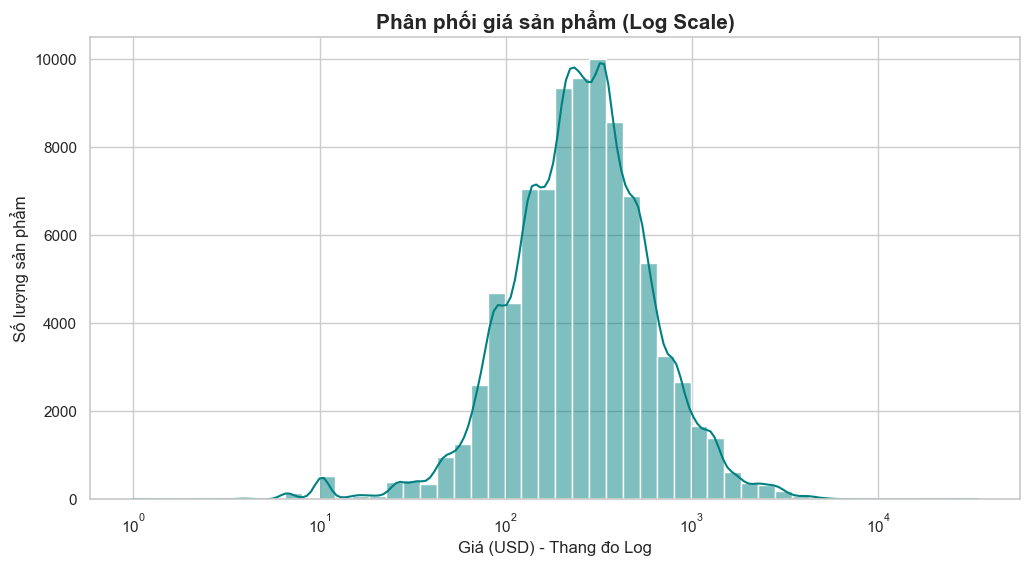

In [7]:
plot_price_distribution(df_main,save_path="image\\price_distribution.png")

BIỂU ĐỒ THỐNG KÊ TOP 10 SẢN PHẨM BÁN CHẠY NHẤT THEO TIÊU CHÍ

Đã lưu biểu đồ tại: image\top_10_catcode.png


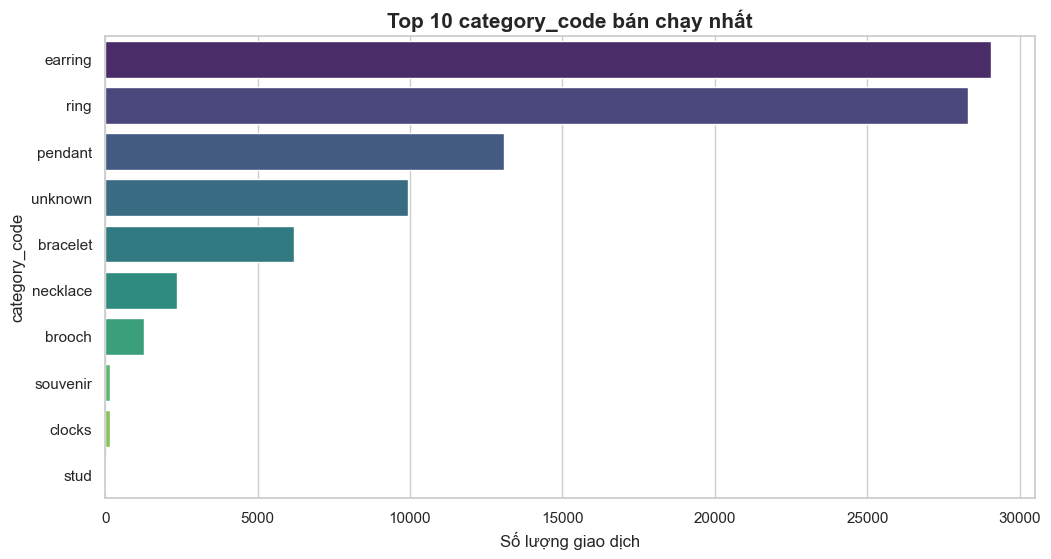

In [8]:
plot_top_categories(df_main, column='category_code', top_n=10, save_path="image\\top_10_catcode.png")

Đã lưu biểu đồ tại: image\top_5_color.png


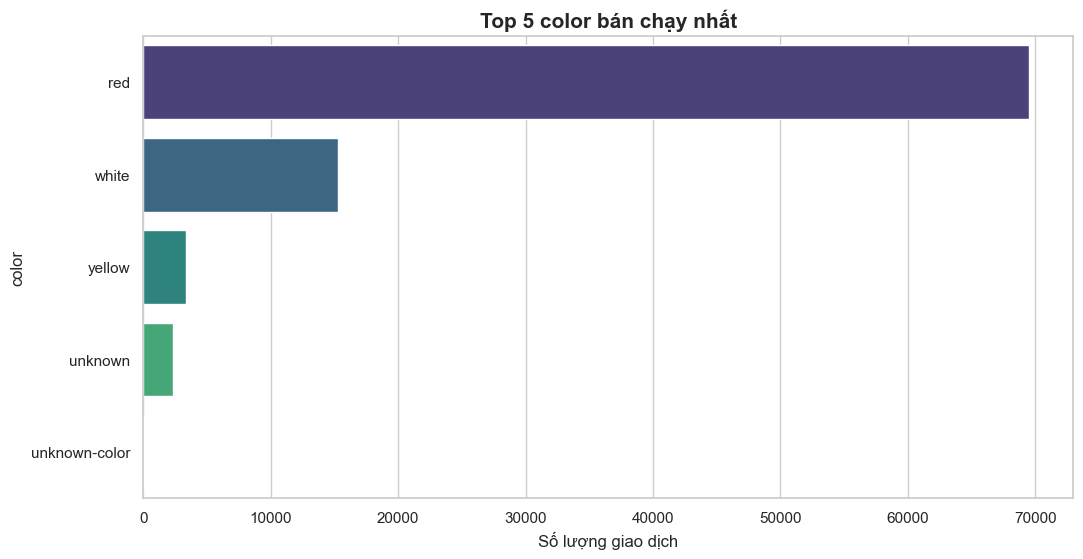

In [9]:
plot_top_categories(df_main, column='color', top_n=5, save_path="image\\top_5_color.png")

BIỂU ĐỒ TƯƠNG QUAN GIỮA CÁC THUỘC TÍNH

Đã lưu biểu đồ tại: image\correlation_heatmap.png


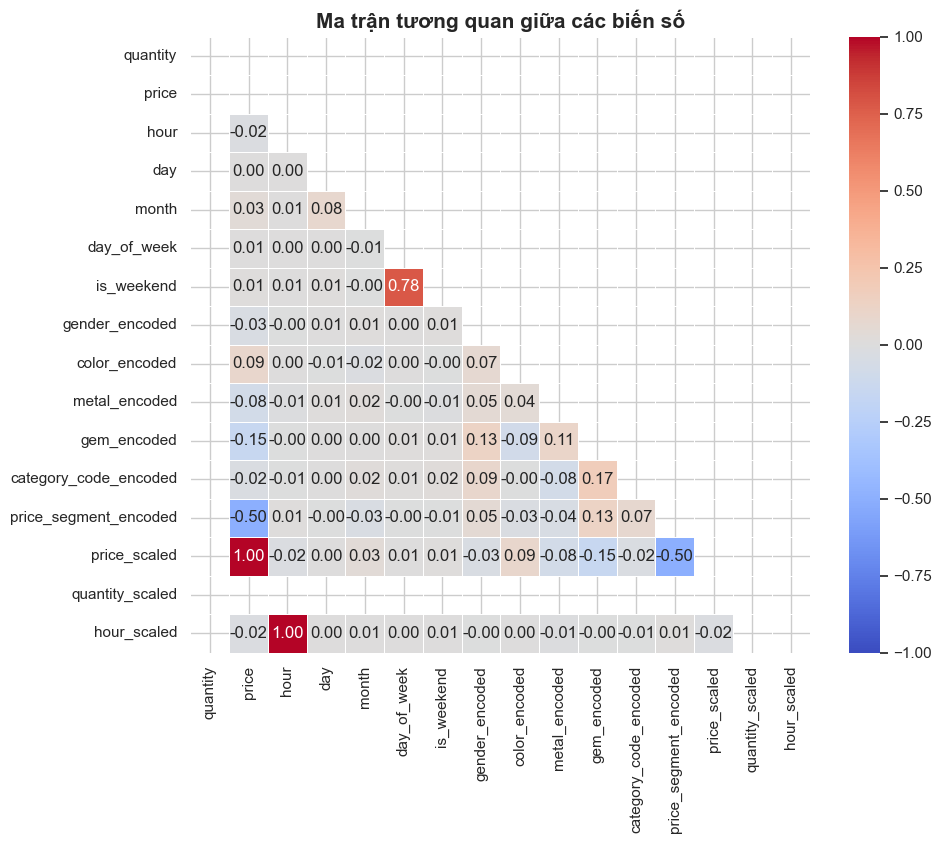

In [10]:
plot_correlation_heatmap(df_main, save_path="image\\correlation_heatmap.png")

Đã lưu biểu đồ tại: image\preprocessing_comparison.png


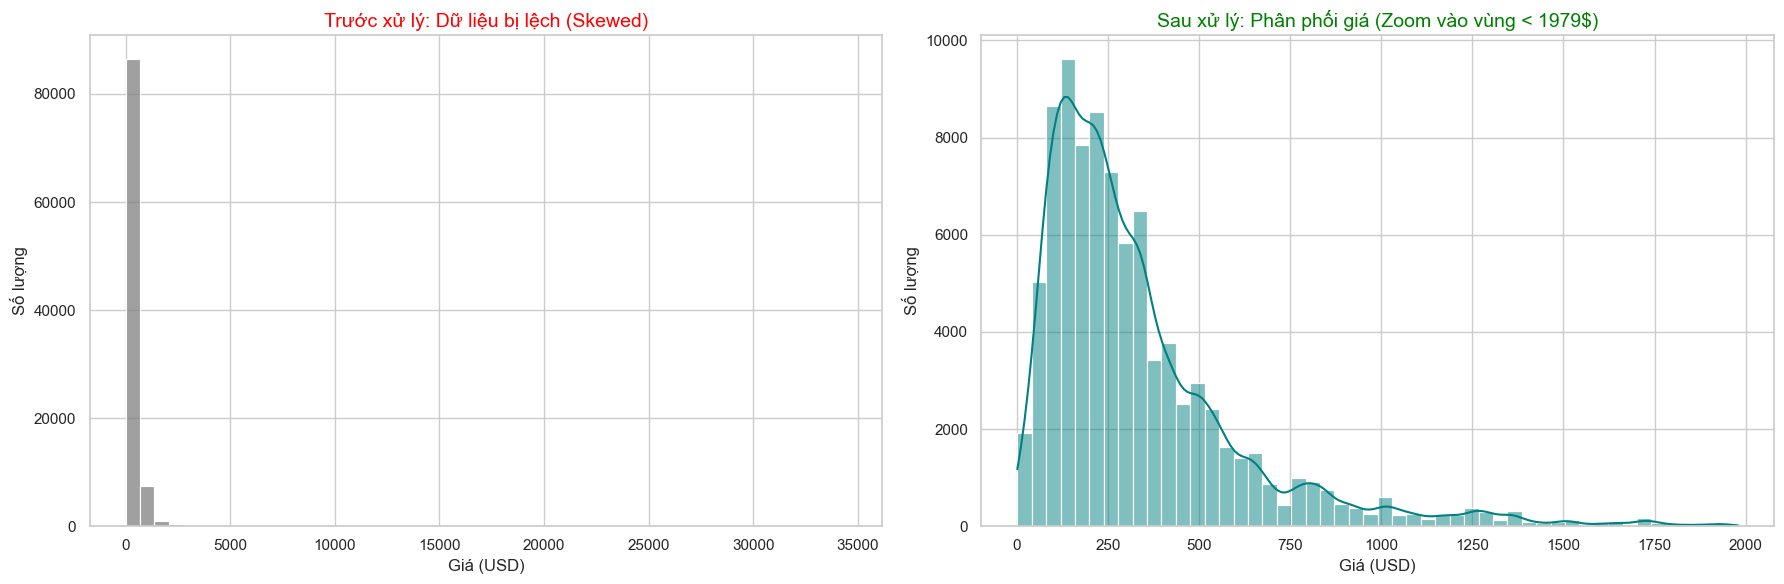

In [11]:
plot_preprocessing_comparison(dataset, df_main, save_path="image\\preprocessing_comparison.png")

Có sự khác biệt giữa 2 biểu đồ là do thay đổi thang đo (chỉ lấy trong khoảng từ 0 - 2000$) chiếm đến 99% bộ dữ liệu

BIỂU ĐỒ THỂ HIỆN XU HƯỚNG MUA HÀNG DỰA VÀO THỜI ĐIỂM TRONG NGÀY/THÁNG HOẶC CUỐI TUẦN

Đã lưu biểu đồ tại: image\sales_trend.png


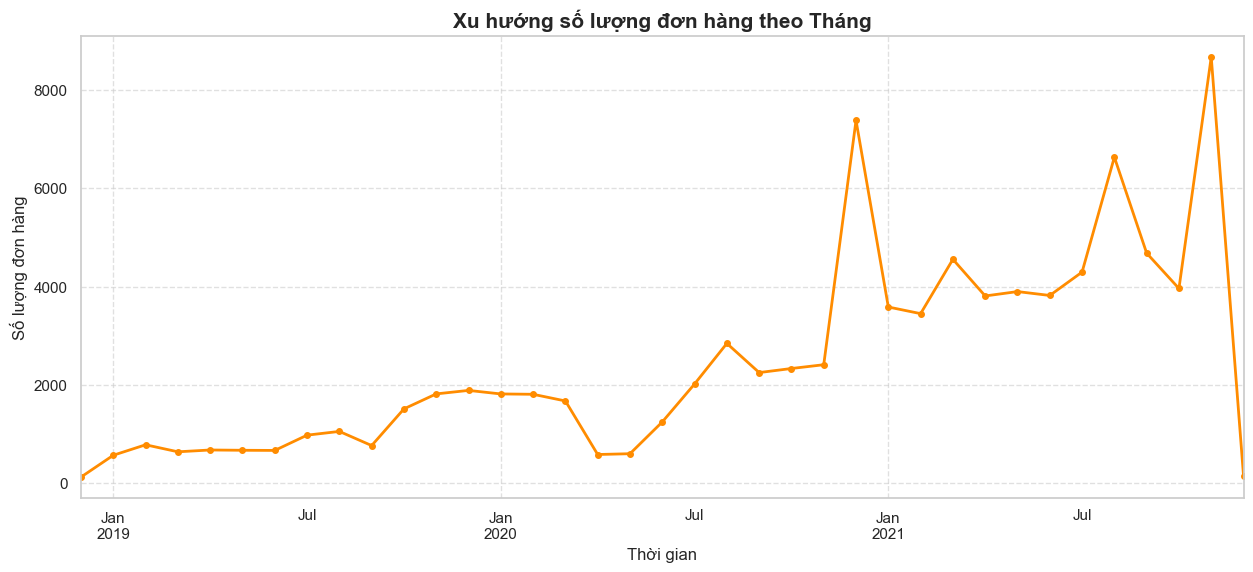

In [5]:
plot_sales_trend(df_main, freq='ME',save_path="image\\sales_trend.png")

Đã lưu biểu đồ tại: image\time_heatmap.png


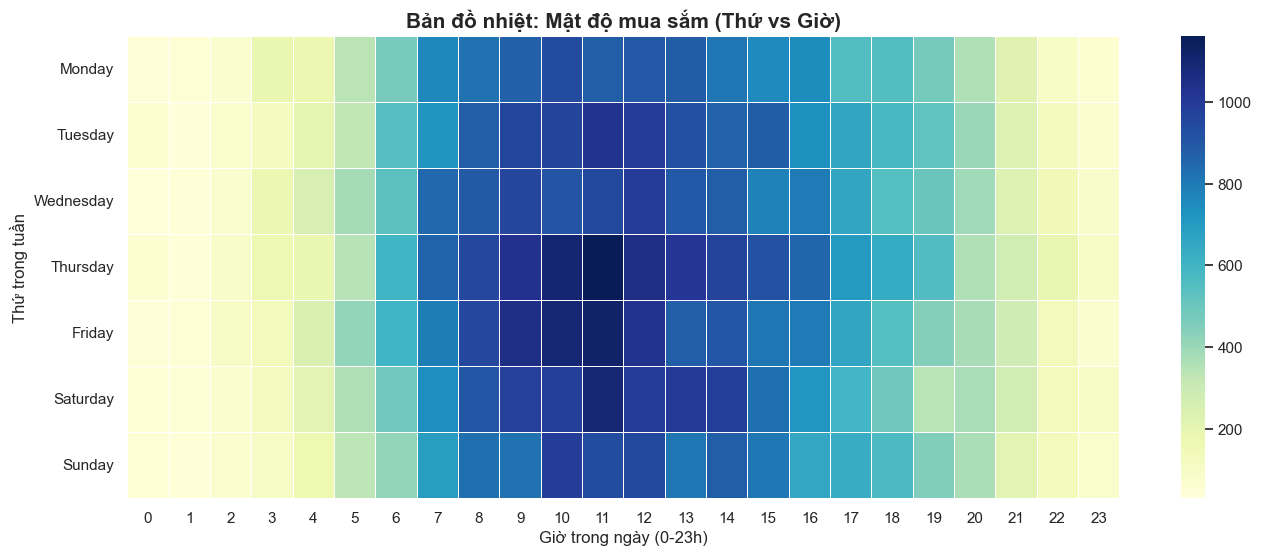

In [13]:
plot_time_heatmap(df_main, save_path="image\\time_heatmap.png")

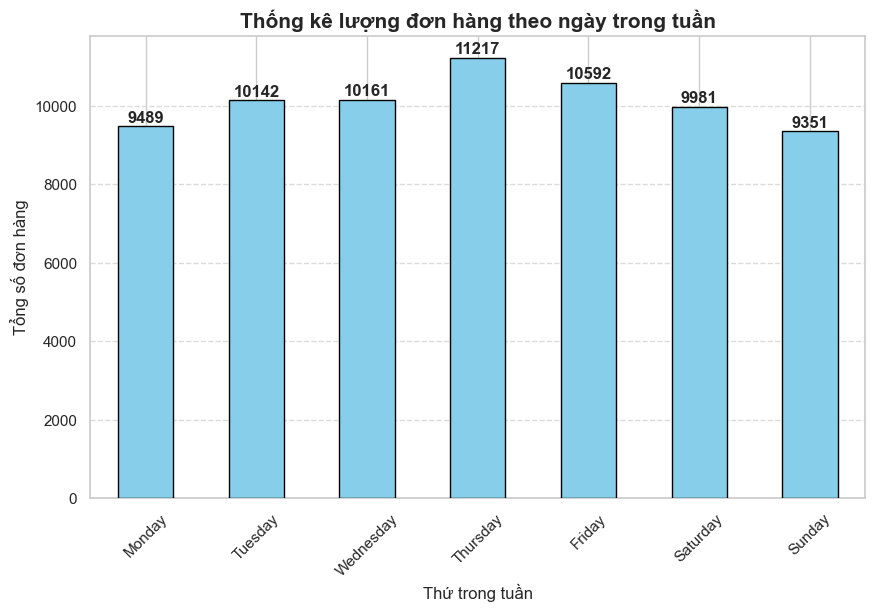

In [14]:
plot_sales_by_weekday(df_main, save_path="image\\sales_by_weekday.png")